# 04 - Analisis ACF / PACF

Estimacion visual de los ordenes p, q (ARIMA) y P, Q (SARIMA)
a partir de los correlogramas de la serie diferenciada.

**Reglas clasicas (Box-Jenkins):**
- ACF con decaimiento exponencial + PACF con corte en lag k → AR(k), p=k
- ACF con corte en lag k + PACF con decaimiento → MA(k), q=k
- Picos en ACF/PACF en lags 12, 24, 36 → ordenes estacionales P, Q

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

NOTEBOOK_DIR = Path(r"c:/Users/usuario/OneDrive/Documentos/tfg-ipc-mcp/tfg-forecasting/02_eda")
ROOT = NOTEBOOK_DIR.parent
MONOREPO = ROOT.parent
sys.path.insert(0, str(MONOREPO))

from shared.constants import DATE_TRAIN_END

plt.rcParams.update({"figure.figsize": (14, 4), "axes.grid": True, "grid.alpha": 0.3})

In [2]:
df = pd.read_parquet(ROOT / "data" / "processed" / "ipc_spain_index.parquet")
train = df.loc[:DATE_TRAIN_END]
y = train["indice_general"]
y.index.freq = "MS"

# Transformaciones
y_diff1 = y.diff().dropna()                    # d=1
y_diff12 = y.diff(12).dropna()                 # D=1
y_diff1_12 = y.diff().diff(12).dropna()        # d=1, D=1

print(f"Nivel: {len(y)} obs | diff(1): {len(y_diff1)} | diff(12): {len(y_diff12)} | diff(1,12): {len(y_diff1_12)}")

Nivel: 228 obs | diff(1): 227 | diff(12): 216 | diff(1,12): 215


## 1. ACF / PACF - Serie en nivel

Esperamos ver ACF con decaimiento muy lento (no estacionaria) y PACF con pico en lag 1.

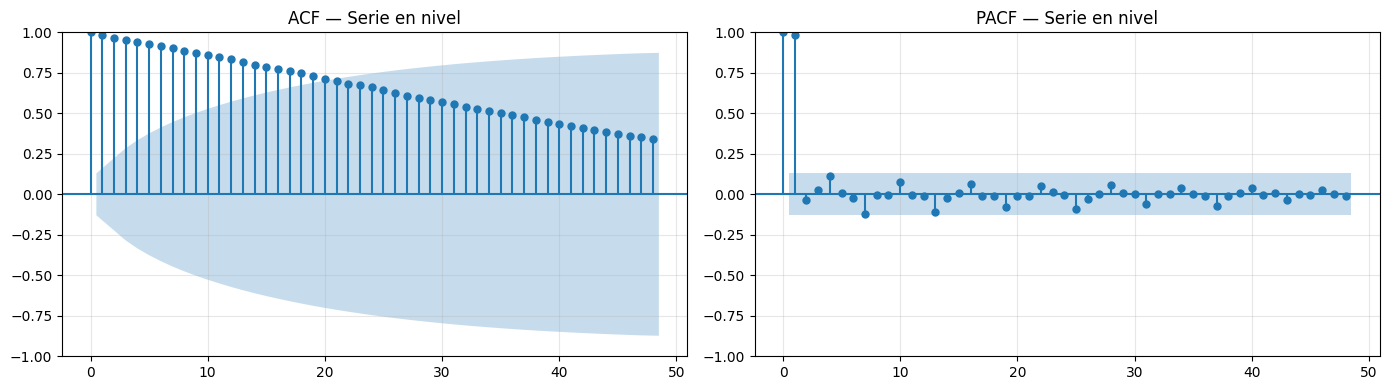

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y, lags=48, ax=axes[0], title="ACF - Serie en nivel")
plot_pacf(y, lags=48, ax=axes[1], title="PACF - Serie en nivel", method="ywm")
plt.tight_layout()
plt.show()

## 2. ACF / PACF - Primera diferencia (d=1)

Aqui buscamos los ordenes p y q. Los picos en lags multiplos de 12 indican componente estacional.

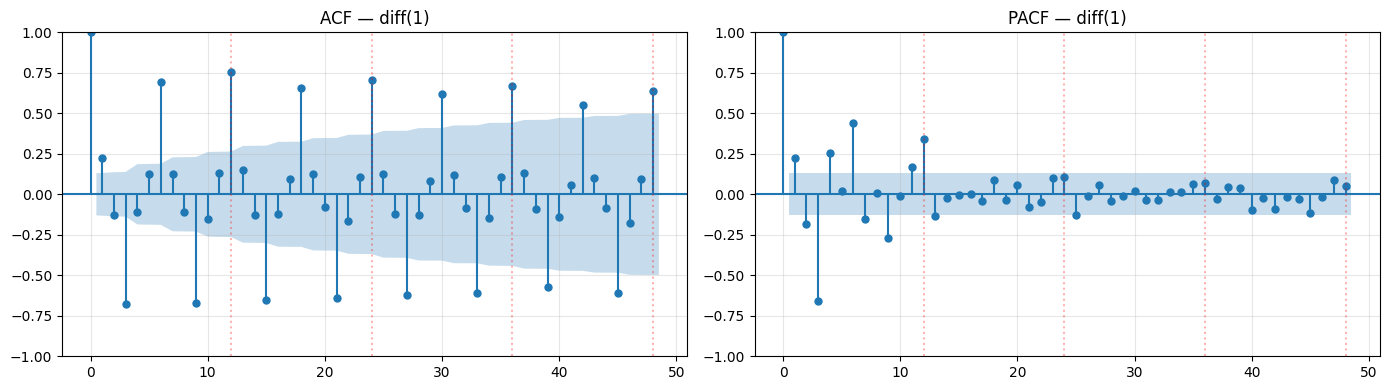

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff1, lags=48, ax=axes[0], title="ACF - diff(1)")
plot_pacf(y_diff1, lags=48, ax=axes[1], title="PACF - diff(1)", method="ywm")

# Marcar lags estacionales
for ax in axes:
    for lag in [12, 24, 36, 48]:
        ax.axvline(lag, color="red", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. ACF / PACF - Diferencia estacional (D=1, lag 12)

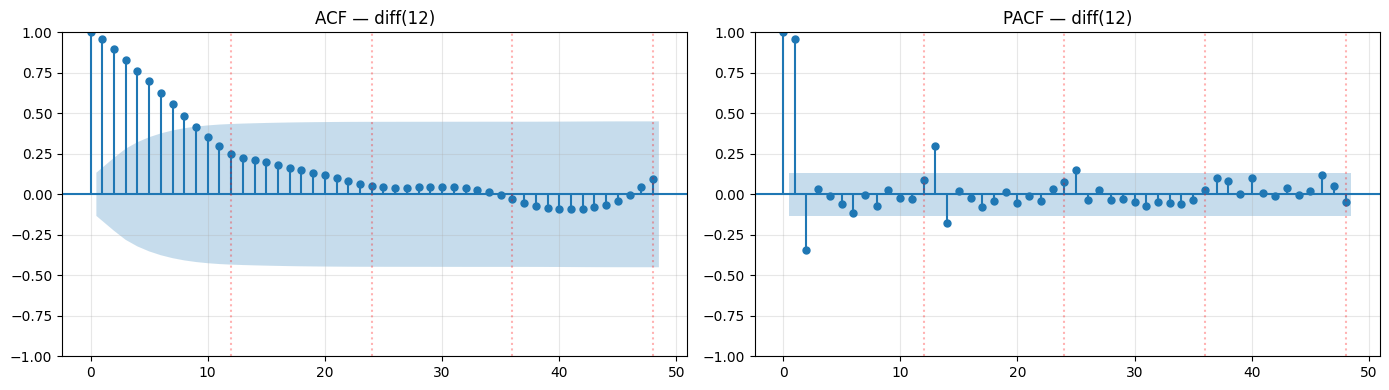

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff12, lags=48, ax=axes[0], title="ACF - diff(12)")
plot_pacf(y_diff12, lags=48, ax=axes[1], title="PACF - diff(12)", method="ywm")

for ax in axes:
    for lag in [12, 24, 36, 48]:
        ax.axvline(lag, color="red", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. ACF / PACF - Doble diferencia (d=1, D=1)

Esta es la serie sobre la que SARIMA opera internamente.
Aqui determinamos los ordenes finales (p, q, P, Q).

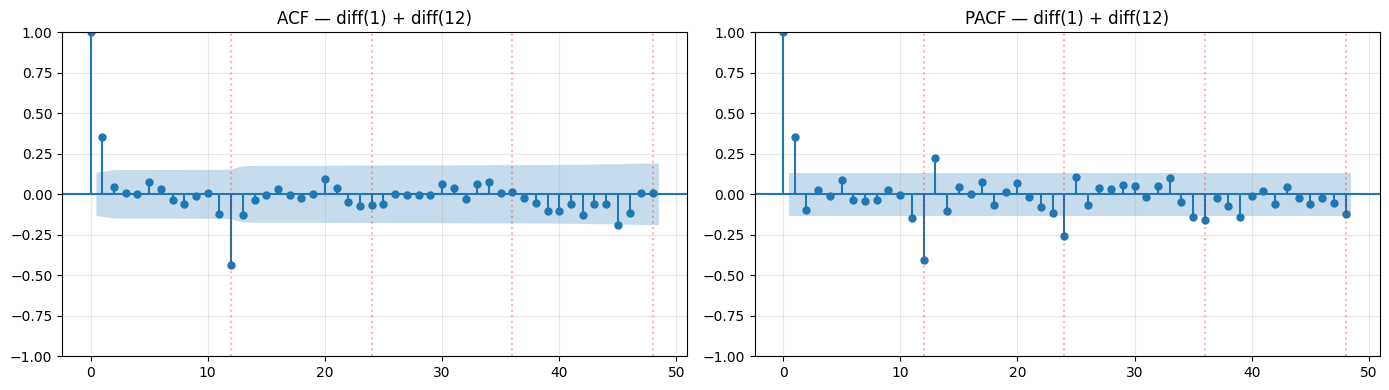

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff1_12, lags=48, ax=axes[0], title="ACF - diff(1) + diff(12)")
plot_pacf(y_diff1_12, lags=48, ax=axes[1], title="PACF - diff(1) + diff(12)", method="ywm")

for ax in axes:
    for lag in [12, 24, 36, 48]:
        ax.axvline(lag, color="red", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Valores numericos de autocorrelacion en lags clave

In [7]:
lags_key = [1, 2, 3, 6, 12, 24, 36]
n = len(y_diff1_12)
ci = 1.96 / np.sqrt(n)  # intervalo de confianza 95%

acf_vals = acf(y_diff1_12, nlags=max(lags_key))
pacf_vals = pacf(y_diff1_12, nlags=max(lags_key), method="ywm")

print(f"Intervalo de confianza 95%: +/- {ci:.4f}")
print(f"{'Lag':>4} {'ACF':>10} {'PACF':>10} {'ACF sig':>10} {'PACF sig':>10}")
print("-" * 50)
for lag in lags_key:
    a, p = acf_vals[lag], pacf_vals[lag]
    a_sig = "*" if abs(a) > ci else ""
    p_sig = "*" if abs(p) > ci else ""
    print(f"{lag:4d} {a:10.4f} {p:10.4f} {a_sig:>10} {p_sig:>10}")

Intervalo de confianza 95%: +/- 0.1337
 Lag        ACF       PACF    ACF sig   PACF sig
--------------------------------------------------
   1     0.3535     0.3535          *          *
   2     0.0428    -0.0939                      
   3     0.0071     0.0274                      
   6     0.0297    -0.0341                      
  12    -0.4383    -0.4028          *          *
  24    -0.0648    -0.2569                     *
  36     0.0164    -0.1613                     *


## 6. Estimacion de ordenes candidatos

In [8]:
# Detectar lags significativos automaticamente
max_lag_regular = 6
max_lag_seasonal = 3  # en multiplos de 12

print("=" * 60)
print("LAGS SIGNIFICATIVOS en serie diff(1)+diff(12)")
print("=" * 60)

acf_full = acf(y_diff1_12, nlags=36)
pacf_full = pacf(y_diff1_12, nlags=36, method="ywm")

# Regular (lags 1-6)
acf_sig_regular = [i for i in range(1, max_lag_regular + 1) if abs(acf_full[i]) > ci]
pacf_sig_regular = [i for i in range(1, max_lag_regular + 1) if abs(pacf_full[i]) > ci]
print(f"\nACF significativos (lags 1-{max_lag_regular}):  {acf_sig_regular}")
print(f"PACF significativos (lags 1-{max_lag_regular}): {pacf_sig_regular}")

# Estacional (lags 12, 24, 36)
seasonal_lags = [12 * i for i in range(1, max_lag_seasonal + 1)]
acf_sig_seasonal = [i for i in seasonal_lags if abs(acf_full[i]) > ci]
pacf_sig_seasonal = [i for i in seasonal_lags if abs(pacf_full[i]) > ci]
print(f"\nACF significativos (estacional):  {acf_sig_seasonal}")
print(f"PACF significativos (estacional): {pacf_sig_seasonal}")

print("\n" + "=" * 60)
print("ORDENES CANDIDATOS")
print("=" * 60)
print(f"d = 1 (confirmado por tests de estacionariedad)")
print(f"D = 1, m = 12")
print(f"p candidatos: {pacf_sig_regular if pacf_sig_regular else [0, 1, 2]}")
print(f"q candidatos: {acf_sig_regular if acf_sig_regular else [0, 1, 2]}")
print(f"P candidatos: basado en PACF estacional -> {[l // 12 for l in pacf_sig_seasonal] if pacf_sig_seasonal else [0, 1]}")
print(f"Q candidatos: basado en ACF estacional  -> {[l // 12 for l in acf_sig_seasonal] if acf_sig_seasonal else [0, 1]}")
print("\nEstos candidatos guian la busqueda de auto_arima (pmdarima).")

LAGS SIGNIFICATIVOS en serie diff(1)+diff(12)

ACF significativos (lags 1-6):  [1]
PACF significativos (lags 1-6): [1]

ACF significativos (estacional):  [12]
PACF significativos (estacional): [12, 24, 36]

ORDENES CANDIDATOS
d = 1 (confirmado por tests de estacionariedad)
D = 1, m = 12
p candidatos: [1]
q candidatos: [1]
P candidatos: basado en PACF estacional -> [1, 2, 3]
Q candidatos: basado en ACF estacional  -> [1]

Estos candidatos guian la busqueda de auto_arima (pmdarima).


## 7. Ljung-Box sobre la serie doblemente diferenciada

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(y_diff1_12, lags=[6, 12, 24], return_df=True)
print("Test de Ljung-Box (H0: no hay autocorrelacion hasta lag k):")
print(lb)
print("\nSi p > 0.05, la diferenciacion ha eliminado la autocorrelacion en ese rango.")

Test de Ljung-Box (H0: no hay autocorrelacion hasta lag k):
      lb_stat     lb_pvalue
6   29.071318  5.897507e-05
12  77.774040  1.095024e-11
24  87.803320  3.319484e-09

Si p > 0.05, la diferenciacion ha eliminado la autocorrelacion en ese rango.


## 8. Conclusion

**Summary of SARIMA orders:**

| Parametro | Valor | Justificacion |
|-----------|-------|---------------|
| d | 1 | Tests ADF/KPSS/PP (notebook 02) |
| D | 1 | Estacionalidad significativa (notebook 03) |
| m | 12 | Frecuencia mensual |
| p | TBD | Corte en PACF regular |
| q | TBD | Corte en ACF regular |
| P | TBD | Corte en PACF estacional |
| Q | TBD | Corte en ACF estacional |

*Completar tras ejecucion. Estos valores se usan como punto de partida;
auto_arima refinara la seleccion por AIC.*